# Lesson 2: Risky Choice — Psychometric Functions and the Noise–Risk Link

## From magnitude comparison to risky choice

The same 64 participants from Barreto-García et al. (2023) also made risky choices
**outside** the scanner.  On each trial they chose between a **sure payoff**
($p_\text{safe} = 1.0$, $n_\text{safe} \in \{5,7,10,14,20,28\}$) and a **risky gamble**
($p_\text{risky} = 0.55$, $n_\text{risky}$ varying).  Payoffs were shown in two
**formats** across separate blocks:

| Format | Representation |
|--------|----------------|
| `non-symbolic` | coin clouds — same format as the magnitude task |
| `symbolic` | Arabic numerals |

The paper's central argument: **the same perceptual noise that limits magnitude
discrimination also distorts risky-choice behaviour**, producing risk aversion as a
by-product of noisy numerical cognition.

## Approach: psychometric functions

Rather than building a full cognitive model (we will do that in lessons 3–4), we start
with the simplest possible analysis: fit a **psychometric function** to each participant's
risky-choice data and extract two numbers:

1. **Noise** ($\nu$) — how imprecise is the observer?  Low $\nu$ → steep curve → precise.
2. **Indifference point** ($\delta^*$, the `bias` parameter) — at what log-ratio does the
   observer switch from preferring safe to preferring risky?

If noise drives risk aversion, then noisier observers (higher $\nu$, lower precision)
should have a higher $\delta^*$ (shifted rightward = more risk-averse).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from scipy.stats import norm as scipy_norm, spearmanr
from bauer.utils.data import load_garcia2022
from bauer.models import PsychometricModel

data_risk = load_garcia2022(task='risk')
print(f"Subjects: {data_risk.index.get_level_values('subject').nunique()},  "
      f"Trials: {len(data_risk)},  "
      f"Formats: {data_risk.index.get_level_values('format').unique().tolist()}")

Subjects: 64,  Trials: 30311,  Formats: ['symbolic', 'non-symbolic']


## Visualise risky-choice data

We plot the proportion of risky choices as a function of the log-ratio
$\log(n_\text{risky} / n_\text{safe})$.  The dashed vertical line marks the
**risk-neutral threshold** $\log(1/0.55) \approx 0.60$ — the point where a
risk-neutral observer is indifferent.

- Curve crosses 0.5 **to the right** of the dashed line → risk-averse
- Curve crosses 0.5 **to the left** → risk-seeking

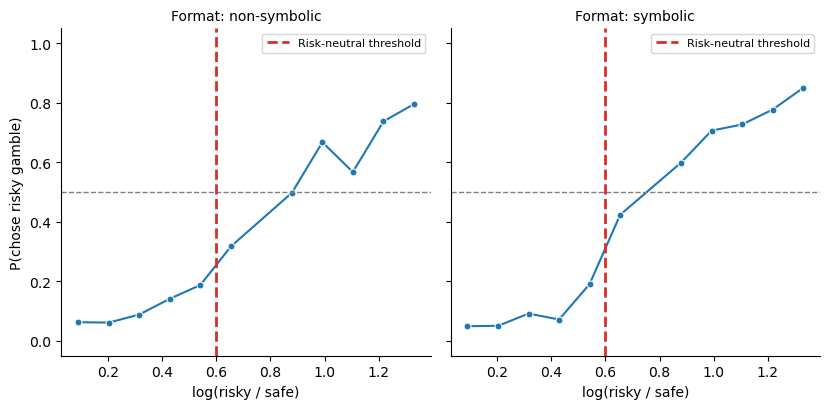

In [2]:
plot_data = data_risk.reset_index(level='format').copy()
plot_data['log(risky/safe)'] = np.log(plot_data['n2'] / plot_data['n1'])
plot_data['bin'] = (pd.cut(plot_data['log(risky/safe)'], bins=12)
                      .map(lambda x: x.mid).astype(float))

grouped = (plot_data.groupby(['format', 'bin'])['choice']
                    .agg(['mean', 'count']).reset_index()
                    .query('count >= 5'))

g = sns.FacetGrid(grouped, col='format', height=4.2, aspect=1.0,
                  palette={'non-symbolic': '#d95f02', 'symbolic': '#1f78b4'})
g.map(sns.lineplot, 'bin', 'mean', marker='o', markersize=5)
for ax in g.axes.flat:
    ax.axhline(.5,              ls='--', c='gray', lw=1)
    ax.axvline(np.log(1/.55),   ls='--', c='#d73027', lw=2, label='Risk-neutral threshold')
    ax.set_ylim(-.05, 1.05)
    ax.legend(fontsize=8)
g.set_axis_labels('log(risky / safe)', 'P(chose risky gamble)')
g.set_titles('Format: {col_name}')
plt.tight_layout()

## The psychometric function for risky choice

bauer's `PsychometricModel` fits:

$$P(\text{chose risky}) = \Phi\!\left(\frac{\log(n_\text{risky}/n_\text{safe}) - \delta^*}{\sqrt{2}\,\nu}\right)$$

where $\Phi$ is the standard-normal CDF.  The two free parameters per subject are:

| Parameter | bauer name | Interpretation |
|-----------|-----------|----------------|
| $\nu$ | `nu` | **Noise** — SD of the internal log-magnitude representation.  Higher = noisier = shallower curve. |
| $\delta^*$ | `bias` | **Indifference point** — the log-ratio at which P(chose risky) = 0.5.  A risk-neutral observer has $\delta^* = \log(1/0.55) \approx 0.60$; larger values indicate risk aversion. |

Note that `bias` is **unconstrained**: it can be positive (risk-averse), zero, or negative
(risk-seeking).  This is important — some participants genuinely prefer the risky option
even when it has lower expected value, and the model can capture that.

### Why this works

On the log scale, choosing the risky option is optimal when:

$$\log n_\text{risky} - \log n_\text{safe} > \log(1/p_\text{risky})$$

i.e. when the risky payoff is large enough to compensate for the lower winning probability.
But this comparison is done with **noisy internal representations**, and the observer may
also have a **bias** toward or away from risk.  The psychometric function captures both
effects in a single curve.

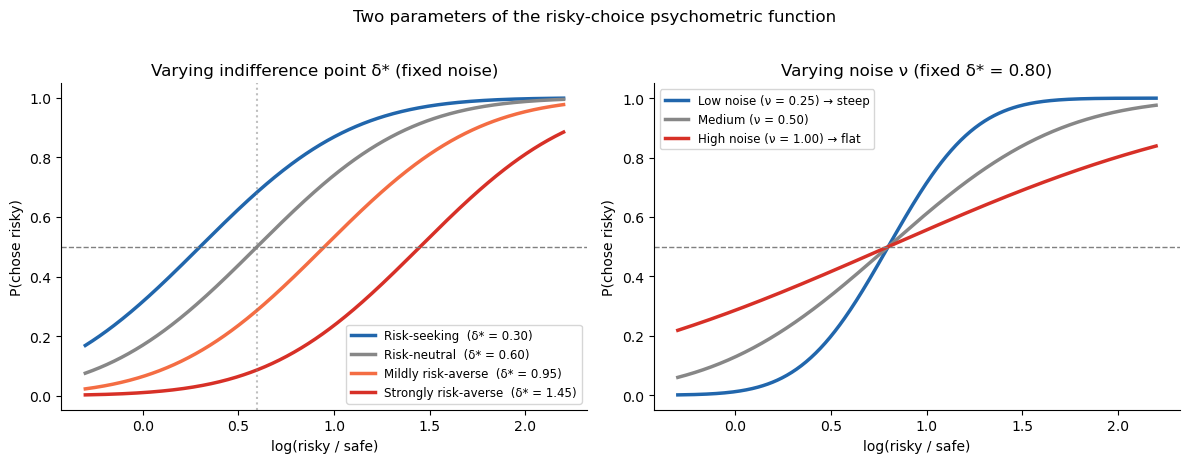

In [3]:
# Illustrate: how noise and bias shape the risky-choice curve
log_r = np.linspace(-.3, 2.2, 400)
ev_threshold = np.log(1/.55)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: varying bias (indifference point) at fixed noise
ax = axes[0]
for delta_star, label, c in [
        (0.3,           'Risk-seeking  (δ* = 0.30)', '#2166ac'),
        (ev_threshold,  f'Risk-neutral  (δ* = {ev_threshold:.2f})', '#878787'),
        (0.95,          'Mildly risk-averse  (δ* = 0.95)', '#f46d43'),
        (1.45,          'Strongly risk-averse  (δ* = 1.45)', '#d73027')]:
    p = scipy_norm.cdf((log_r - delta_star) * 1.6)
    ax.plot(log_r, p, color=c, lw=2.5, label=label)
ax.axhline(.5, ls='--', c='gray', lw=1)
ax.axvline(ev_threshold, ls=':', c='gray', lw=1.5, alpha=.5)
ax.set_xlabel('log(risky / safe)'); ax.set_ylabel('P(chose risky)')
ax.set_title('Varying indifference point δ* (fixed noise)')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

# Right: varying noise at fixed bias
ax = axes[1]
for nu, label, c in [
        (0.25, 'Low noise (ν = 0.25) → steep', '#2166ac'),
        (0.50, 'Medium (ν = 0.50)', '#878787'),
        (1.00, 'High noise (ν = 1.00) → flat', '#d73027')]:
    sigma = np.sqrt(2) * nu
    p = scipy_norm.cdf((log_r - 0.8) / sigma)
    ax.plot(log_r, p, color=c, lw=2.5, label=label)
ax.axhline(.5, ls='--', c='gray', lw=1)
ax.set_xlabel('log(risky / safe)'); ax.set_ylabel('P(chose risky)')
ax.set_title('Varying noise ν (fixed δ* = 0.80)')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

plt.suptitle('Two parameters of the risky-choice psychometric function', fontsize=12, y=1.02)
plt.tight_layout()

## Fitting psychometric functions — separately per format

Because symbolic and non-symbolic formats produce different noise levels, we fit
`PsychometricModel` **separately** for each format.  This gives us per-subject estimates
of $\nu$ (noise) and $\delta^*$ (indifference point) within each format, which we can
then correlate with each other and with magnitude-task precision.

In [4]:
# Prepare data: x1 = log(safe), x2 = log(risky), split by format
def prep_risk_data(data):
    df = data.reset_index()
    df['x1'] = np.log(df['n1'].astype(float))   # log(safe)
    df['x2'] = np.log(df['n2'].astype(float))   # log(risky)
    return df.set_index([c for c in data.index.names if c in df.columns])

data_sym    = prep_risk_data(data_risk.xs('symbolic',     level='format'))
data_nonsym = prep_risk_data(data_risk.xs('non-symbolic', level='format'))

print(f"Symbolic:      {len(data_sym)} trials, "
      f"{data_sym.index.get_level_values('subject').nunique()} subjects")
print(f"Non-symbolic:  {len(data_nonsym)} trials, "
      f"{data_nonsym.index.get_level_values('subject').nunique()} subjects")

Symbolic:      15161 trials, 64 subjects
Non-symbolic:  15150 trials, 64 subjects


In [5]:
# Fit psychometric models — one per format
from bauer.models import PsychometricModel

model_sym = PsychometricModel(paradigm=data_sym)
model_sym.build_estimation_model(data=data_sym, hierarchical=True)
idata_sym = model_sym.sample(draws=500, tune=500, chains=4, progressbar=False)
print("Symbolic fit done")

model_nonsym = PsychometricModel(paradigm=data_nonsym)
model_nonsym.build_estimation_model(data=data_nonsym, hierarchical=True)
idata_nonsym = model_nonsym.sample(draws=500, tune=500, chains=4, progressbar=False)
print("Non-symbolic fit done")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [nu_mu_untransformed, nu_sd, nu_offset, bias_mu, bias_sd, bias_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 59 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


...

NUTS: [nu_mu_untransformed, nu_sd, nu_offset, bias_mu, bias_sd, bias_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 61 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Non-symbolic fit done


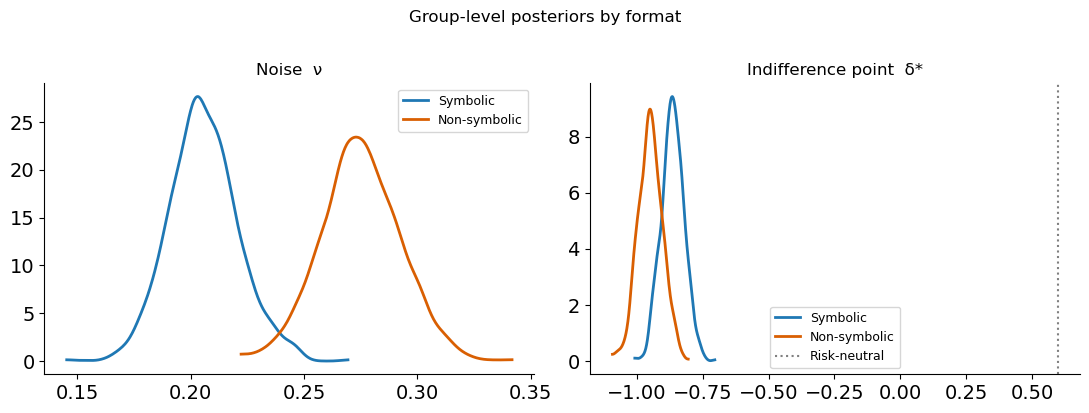

In [6]:
# Group-level posteriors: compare formats
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ev_threshold = np.log(1/.55)

for ax, param, title in zip(axes, ['nu_mu', 'bias_mu'],
                             ['Noise  ν', 'Indifference point  δ*']):
    sym_vals    = idata_sym.posterior[param].values.ravel()
    nonsym_vals = idata_nonsym.posterior[param].values.ravel()
    az.plot_kde(sym_vals,    label='Symbolic',     plot_kwargs={'color': '#1f78b4', 'lw': 2}, ax=ax)
    az.plot_kde(nonsym_vals, label='Non-symbolic',  plot_kwargs={'color': '#d95f02', 'lw': 2}, ax=ax)
    if param == 'bias_mu':
        ax.axvline(ev_threshold, ls=':', c='gray', lw=1.5, label='Risk-neutral')
    ax.set_title(title); ax.legend(fontsize=9); sns.despine(ax=ax)

plt.suptitle('Group-level posteriors by format', fontsize=12, y=1.02)
plt.tight_layout()

### Format effect

Symbolic (Arabic numeral) payoffs produce **lower noise** and a **lower indifference
point** — i.e. less risk aversion.  This is exactly what the theory predicts: symbolic
numbers are encoded more precisely, so there is less Bayesian shrinkage, and the
perceived advantage of the risky option is less compressed.

### Difference distributions

Overlaying two posteriors can be misleading: even when the marginals overlap substantially,
the **difference** may be clearly non-zero.  This is especially important when the two
quantities are correlated (e.g. because they come from the same participants).  Here the
two formats are fitted as separate models, so the posteriors are independent — but showing
the difference distribution is still clearer than eyeballing overlap.

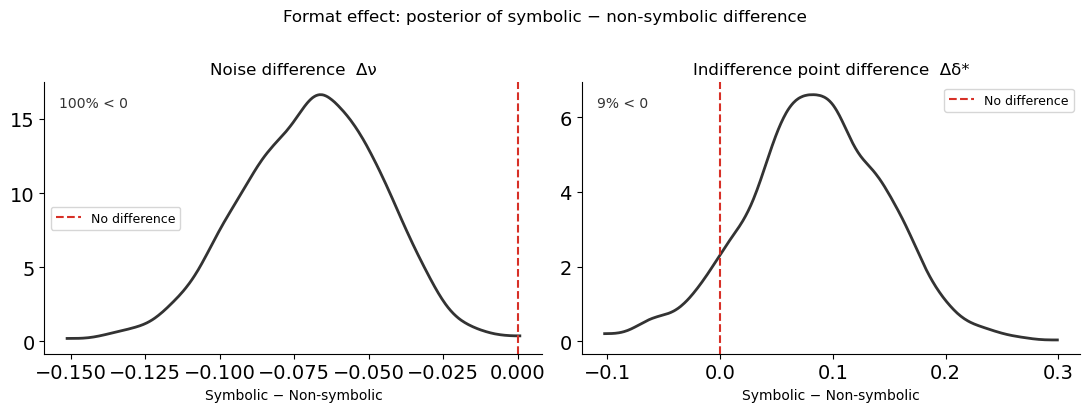

In [7]:
# Difference distributions: symbolic minus non-symbolic
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, param, title in zip(axes, ['nu_mu', 'bias_mu'],
                             ['Noise difference  Δν', 'Indifference point difference  Δδ*']):
    sym_vals    = idata_sym.posterior[param].values.ravel()
    nonsym_vals = idata_nonsym.posterior[param].values.ravel()
    # Sample from both and compute difference
    n = min(len(sym_vals), len(nonsym_vals))
    diff = sym_vals[:n] - nonsym_vals[:n]
    az.plot_kde(diff, plot_kwargs={'color': '#333333', 'lw': 2}, ax=ax)
    ax.axvline(0, ls='--', c='#d73027', lw=1.5, label='No difference')
    pct_below = (diff < 0).mean() * 100
    ax.set_title(title)
    ax.set_xlabel('Symbolic − Non-symbolic')
    ax.text(0.03, 0.95, f'{pct_below:.0f}% < 0', transform=ax.transAxes,
            va='top', fontsize=10, color='#333333')
    ax.legend(fontsize=9); sns.despine(ax=ax)

plt.suptitle('Format effect: posterior of symbolic − non-symbolic difference', fontsize=12, y=1.02)
plt.tight_layout()

For both parameters, the difference distribution sits almost entirely below zero:
symbolic payoffs produce lower noise *and* a less risk-averse indifference point.
The `RiskRegressionModel` at the end of this lesson tests this contrast within a single
model, which is the cleanest approach.

## Key result: noise predicts risk aversion (within each format)

We extract each subject's posterior mean for `nu` and `bias`, separately for each format,
and test whether noisier observers are more risk-averse **within** each format.

In [8]:
def extract_subject_params(idata, format_label):
    subjects = idata.posterior['nu'].coords['subject'].values
    nu_flat   = idata.posterior['nu'].values.reshape(-1, len(subjects))
    bias_flat = idata.posterior['bias'].values.reshape(-1, len(subjects))
    df = pd.DataFrame({
        'subject':   subjects,
        'format':    format_label,
        'nu_mean':   nu_flat.mean(0),
        'nu_lo':     np.percentile(nu_flat, 3, 0),
        'nu_hi':     np.percentile(nu_flat, 97, 0),
        'bias_mean': bias_flat.mean(0),
        'bias_lo':   np.percentile(bias_flat, 3, 0),
        'bias_hi':   np.percentile(bias_flat, 97, 0),
    })
    df['prec']    = 1 / df['nu_mean']
    df['prec_lo'] = 1 / df['nu_hi']
    df['prec_hi'] = 1 / df['nu_lo']
    return df

df_sym_params    = extract_subject_params(idata_sym,    'symbolic')
df_nonsym_params = extract_subject_params(idata_nonsym, 'non-symbolic')

for label, df in [('Symbolic', df_sym_params), ('Non-symbolic', df_nonsym_params)]:
    rho, p = spearmanr(df['nu_mean'], df['bias_mean'])
    print(f"{label:15s}  noise-bias ρ = {rho:.3f} (p = {p:.4f})")

Symbolic         noise-bias ρ = -0.402 (p = 0.0010)
Non-symbolic     noise-bias ρ = -0.383 (p = 0.0018)


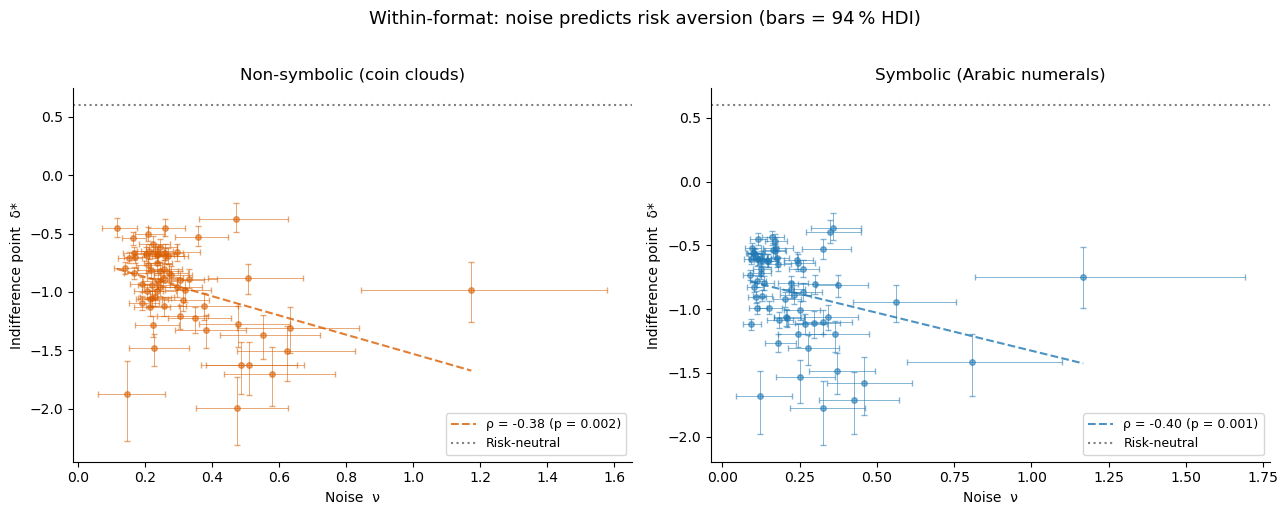

In [9]:
def scatter_hdi(ax, x, y, xerr, yerr, color, xlabel, ylabel, title,
                hline=None):
    ax.errorbar(x, y, xerr=xerr, yerr=yerr,
                fmt='o', ms=4, alpha=.55, elinewidth=.7, capsize=2,
                color=color, ecolor=color)
    rho, p = spearmanr(x, y)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m*xs + b, '--', color=color, lw=1.5, alpha=.8,
            label=f'ρ = {rho:.2f} (p = {p:.3f})')
    if hline is not None:
        ax.axhline(hline, ls=':', c='gray', lw=1.5, label='Risk-neutral')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=9); sns.despine(ax=ax)

ev_threshold = np.log(1/.55)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in zip(
        axes,
        [df_nonsym_params, df_sym_params],
        ['Non-symbolic (coin clouds)', 'Symbolic (Arabic numerals)'],
        ['#d95f02', '#1f78b4']):
    scatter_hdi(
        ax,
        x    = df['nu_mean'],
        y    = df['bias_mean'],
        xerr = np.array([df['nu_mean'] - df['nu_lo'], df['nu_hi'] - df['nu_mean']]),
        yerr = np.array([df['bias_mean'] - df['bias_lo'], df['bias_hi'] - df['bias_mean']]),
        color  = color,
        xlabel = 'Noise  ν',
        ylabel = 'Indifference point  δ*',
        title  = label,
        hline  = ev_threshold,
    )

plt.suptitle('Within-format: noise predicts risk aversion (bars = 94 % HDI)',
             fontsize=13, y=1.02)
plt.tight_layout()

## Interpreting the indifference point: from log-space to intuition

The `bias` parameter lives in **log-ratio space**, which is not immediately intuitive.
Three reparameterisations make it more concrete:

### 1. Indifference ratio: "how much larger must the risky option be?"

The indifference point is $\delta^* = -\text{bias}$ in log-ratio space.  Exponentiating
gives the **indifference ratio**:

$$R^* = e^{\delta^*} = e^{-\text{bias}}$$

This is the factor by which the risky payoff must exceed the safe payoff for the observer
to be indifferent.  A risk-neutral observer (with $p_\text{risky} = 0.55$) has
$R^* = 1/0.55 \approx 1.82$ — the risky option must be about **82 % larger**.  A
risk-averse observer requires an even larger premium.

### 2. Risk-neutral probability (RNP)

The **RNP** answers: "at what winning probability would a risk-neutral agent make the same
choices as this observer?"

$$\text{RNP} = e^{\text{bias}}$$

- RNP = 0.55 → risk-neutral (the observer acts as if the gamble wins at its true rate)
- RNP < 0.55 → risk-averse (acts as if the gamble wins *less* often than it actually does)
- RNP > 0.55 → risk-seeking

The RNP is simply the reciprocal of the indifference ratio scaled by the actual probability:
$\text{RNP} = p_\text{risky} / R^* \times (1/p_\text{safe})$.  But $e^{\text{bias}}$ is
the most direct computation.

### 3. Certainty equivalent discount

How many cents on the euro does the observer implicitly discount the risky option?
$\text{CE discount} = 1 - \text{RNP} / p_\text{risky} = 1 - e^{\text{bias}} / 0.55$.
A discount of 20 % means the observer treats every risky euro as worth only 80 cents.

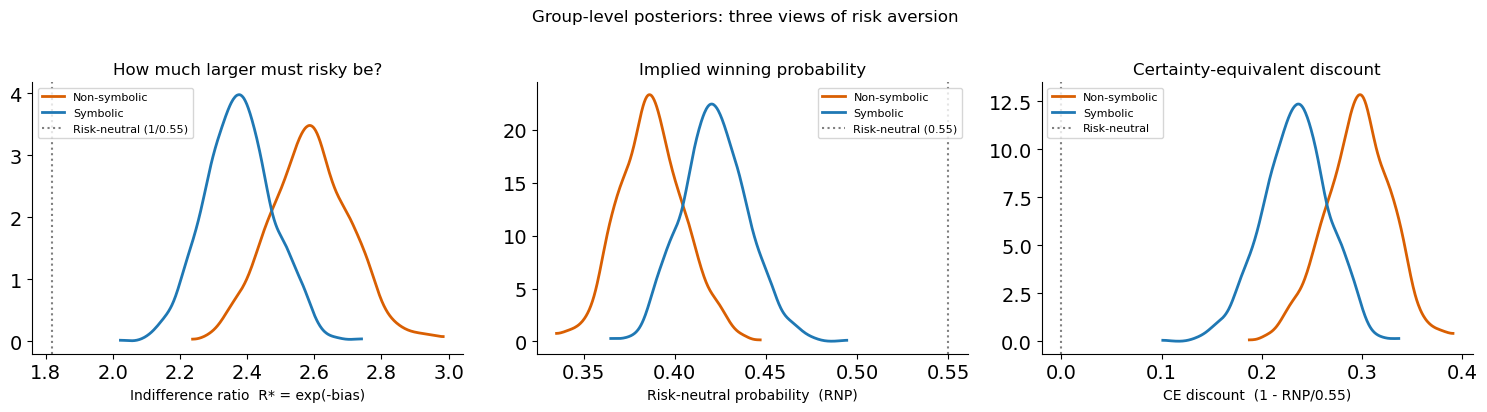

In [10]:
# Posterior distributions of the reparameterised group-level bias
bias_sym    = idata_sym.posterior['bias_mu'].values.ravel()
bias_nonsym = idata_nonsym.posterior['bias_mu'].values.ravel()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Indifference ratio R* = exp(-bias)
ax = axes[0]
for vals, label, c in [(bias_nonsym, 'Non-symbolic', '#d95f02'),
                        (bias_sym,    'Symbolic',     '#1f78b4')]:
    ratio = np.exp(-vals)
    az.plot_kde(ratio, label=label, plot_kwargs={'color': c, 'lw': 2}, ax=ax)
ax.axvline(1/0.55, ls=':', c='gray', lw=1.5, label='Risk-neutral (1/0.55)')
ax.set_xlabel('Indifference ratio  R* = exp(-bias)')
ax.set_title('How much larger must risky be?')
ax.legend(fontsize=8); sns.despine(ax=ax)

# 2. RNP = exp(bias)
ax = axes[1]
for vals, label, c in [(bias_nonsym, 'Non-symbolic', '#d95f02'),
                        (bias_sym,    'Symbolic',     '#1f78b4')]:
    rnp = np.exp(vals)
    az.plot_kde(rnp, label=label, plot_kwargs={'color': c, 'lw': 2}, ax=ax)
ax.axvline(0.55, ls=':', c='gray', lw=1.5, label='Risk-neutral (0.55)')
ax.set_xlabel('Risk-neutral probability  (RNP)')
ax.set_title('Implied winning probability')
ax.legend(fontsize=8); sns.despine(ax=ax)

# 3. CE discount = 1 - RNP/0.55
ax = axes[2]
for vals, label, c in [(bias_nonsym, 'Non-symbolic', '#d95f02'),
                        (bias_sym,    'Symbolic',     '#1f78b4')]:
    rnp = np.exp(vals)
    discount = 1 - rnp / 0.55
    az.plot_kde(discount, label=label, plot_kwargs={'color': c, 'lw': 2}, ax=ax)
ax.axvline(0, ls=':', c='gray', lw=1.5, label='Risk-neutral')
ax.set_xlabel('CE discount  (1 - RNP/0.55)')
ax.set_title('Certainty-equivalent discount')
ax.legend(fontsize=8); sns.despine(ax=ax)

plt.suptitle('Group-level posteriors: three views of risk aversion', fontsize=12, y=1.02)
plt.tight_layout()

## Bonus: RiskRegressionModel for the format effect

Instead of fitting two separate models, bauer's `RiskRegressionModel` lets you test the
format effect *within a single model* using a patsy formula.  This gives a direct posterior
on the format contrast — cleaner than comparing two separate fits.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [evidence_sd_mu, evidence_sd_sd, evidence_sd_offset, prior_sd_mu, prior_sd_sd, prior_sd_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 929 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


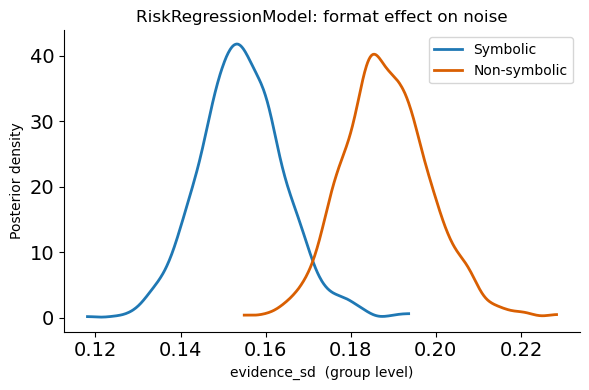

In [11]:
from bauer.models import RiskRegressionModel

data_reg = data_risk.reset_index(level='format')
model_reg = RiskRegressionModel(
    paradigm=data_reg,
    regressors={'evidence_sd': 'C(format)'},
    prior_estimate='klw',
    fit_seperate_evidence_sd=False,
)
model_reg.build_estimation_model(data=data_reg, hierarchical=True)
idata_reg = model_reg.sample(draws=500, tune=500, chains=4, progressbar=False)

# Posterior of evidence_sd at each format condition
conditions = pd.DataFrame({'format': ['symbolic', 'non-symbolic']})
pars_cond  = model_reg.get_conditionwise_parameters(idata_reg, conditions, group=True)

sd_sym    = pars_cond.loc['evidence_sd']['symbolic'].values
sd_nonsym = pars_cond.loc['evidence_sd']['non-symbolic'].values

fig, ax = plt.subplots(figsize=(6, 4))
az.plot_kde(sd_sym,    label='Symbolic',     plot_kwargs={'color': '#1f78b4', 'lw': 2}, ax=ax)
az.plot_kde(sd_nonsym, label='Non-symbolic',  plot_kwargs={'color': '#d95f02', 'lw': 2}, ax=ax)
ax.set_xlabel('evidence_sd  (group level)')
ax.set_ylabel('Posterior density')
ax.set_title('RiskRegressionModel: format effect on noise')
ax.legend(); sns.despine(); plt.tight_layout()

## Why noise produces risk aversion: the KLW mechanism

The correlation between noise and risk aversion is not a statistical accident — it has a
mechanistic explanation.  The **KLW model** (Khaw, Li & Woodford, 2021) shows that a
Bayesian observer with noisy magnitude representations will *systematically undervalue*
risky prospects:

1. Both the safe and risky payoffs are perceived with noise $\nu$ on the log scale.
2. A Bayesian prior pulls both percepts toward the mean of the payoff distribution.
3. Because the risky payoff is typically *larger* than the safe payoff, it gets pulled
   *down* more (toward the mean) than the safe payoff gets pulled *up*.
4. This asymmetric compression shrinks the perceived advantage of the risky option,
   shifting the indifference point rightward — i.e. producing risk aversion.

The amount of shrinkage is controlled by the ratio $\nu^2 / \sigma_0^2$ (noise vs.
prior width).  More noise $\rightarrow$ more shrinkage $\rightarrow$ more risk aversion.
This is exactly the correlation we see in the scatter plots above.

Critically, risk aversion here is not a preference — it is a **perceptual distortion**.
The observer is doing the best they can with noisy information, and the Bayesian-optimal
strategy happens to look risk-averse from the outside.

## Summary

1. A **psychometric function** fitted to risky choices gives two parameters per subject:
   noise ($\nu$) and indifference point ($\delta^*$).
2. **Format matters**: symbolic payoffs produce lower noise and less risk aversion than
   non-symbolic coin clouds.
3. **Within each format**: noisier subjects have higher $\delta^*$ (more risk-averse).
4. **RiskRegressionModel** provides a principled single-model test of the format effect.
5. The **KLW model** explains *why*: Bayesian shrinkage under noise compresses the
   perceived advantage of risky options.

In [Lesson 3](lesson3.ipynb) we move to a richer dataset (de Hollander et al., 2024, bioRxiv) where
**presentation order** is randomised, allowing bauer's `RiskModel` with separate
$\nu_1, \nu_2$ to capture striking order $\times$ stake-size interactions.